# IMPORT IMPORTANT MODULE's

In [1]:
%pip install xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

### Load Dataset

In [3]:
train = pd.read_csv("../data/train_accident.csv")

test = pd.read_csv("../data/test_accident.csv")


In [4]:
print("Training Dataset Shape :", train.shape)
print("Testing Dataset Shape  :", test.shape)

Training Dataset Shape : (51490, 42)
Testing Dataset Shape  : (77235, 42)


In [5]:
train.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Type,Cross-Street Name,Off-Road Description,...,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Equipment Problems,Latitude,Longitude,Location,Fault
0,MP060D,10196,Montgomery County Police,Injury Crash,06/05/2017 04:27:00 PM,Maryland (State),OLD HUNDRED RD,County,THURSTON RD,12305 SHOREFIELD RD,...,No,No,2005,GMC,TRUCK,NO MISUSE,39.263378,-77.344203,3.6383 7.4233,1
1,MP000X,20080,Montgomery County Police,Injury Crash,02/22/2020 10:00:00 AM,County,JANET RD,County,FLACK ST,NaN,...,No,Yes,2018,FORD,FIESTA,NO MISUSE,39.068913,-77.063227,3.0862 7.324,1
2,MP070N,10103,Montgomery County Police,Property Damage Crash,06/11/2017 08:21:00 AM,Maryland (State),COLESVILLE RD,Maryland (State),STRUC #15082,NaN,...,No,No,2016,NEW FLYER,TBU,NO MISUSE,38.993578,-77.032718,3.9583 7.3783,0
3,MP130Y,10208,Montgomery County Police,Injury Crash,05/10/2019 07:30:00 AM,County,PARKLAND DR,County,FRANKFORT DR,NaN,...,No,No,2001,CHEV,SUBURBAN,OTHER,39.083480,-77.086933,"3.84,-70633",1
4,MP770Y,1091,Montgomery County Police,Injury Crash,08/02/2016 05:00:00 PM,Maryland (State),OLD GEORGETOWN RD,County,MCKINLEY ST,NaN,...,No,No,2013,KIA,RIO,NO MISUSE,38.996942,-77.109168,3.9917 7.0183,0


In [6]:
test.head()

,Id,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Type,Cross-Street Name,...,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Equipment Problems,Latitude,Longitude,Location
0,0,MP810M,NaN,MONTGOMERY,Property Damage Crash,12/16/2015 05:42:00 PM,County,WHITTIER BLVD,Maryland (State),WILSON LA,...,25,No,No,2004,LEXUS,RX330,NO MISUSE,38.988440,-77.127668,"3.84,-71763"
1,1,MP2001,NaN,Montgomery County Police,Property Damage Crash,05/01/2016 07:25:00 PM,County,RAILROAD ST,Municipality,E DIAMOND AVE,...,25,No,No,2001,MITSUBISHI,MIRAGE,NO MISUSE,39.094075,-77.205783,3.905 7.0733
2,2,MP6404,10125,Montgomery County Police,Property Damage Crash,03/16/2018 02:30:00 PM,Maryland (State),GEORGIA AVE,County,ARCOLA AVE,...,35,No,No,2016,FRIEGHTLINER,AMBULANCE,NO MISUSE,39.047180,-77.052688,"3.41,-70283"
3,3,MP0405,10270,Montgomery County Police,Property Damage Crash,05/25/2018 05:00:00 PM,NaN,NaN,NaN,NaN,...,25,No,No,2004,FORD,CN,NaN,39.178007,-77.238475,3.7067 7.345
4,4,MP090D,10374,Montgomery County Police,Property Damage Crash,09/23/2017 05:40:00 PM,Interstate (State),EISENHOWER MEMORIAL HWY,Maryland (State),MONTROSE RD,...,55,No,No,2008,UTIL,TL,UNKNOWN,39.056134,-77.154043,3.5143 7.5022


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 51490 entries, 0 to 51489
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Report Number                   51490 non-null  str    
 1   Local Case Number               45037 non-null  str    
 2   Agency Name                     51490 non-null  str    
 3   ACRS Report Type                51490 non-null  str    
 4   Crash Date/Time                 51490 non-null  str    
 5   Route Type                      46522 non-null  str    
 6   Road Name                       46988 non-null  str    
 7   Cross-Street Type               46471 non-null  str    
 8   Cross-Street Name               46968 non-null  str    
 9   Off-Road Description            6950 non-null   str    
 10  Municipality                    7567 non-null   str    
 11  Related Non-Motorist            3648 non-null   str    
 12  Collision Type                  51191 non-n

In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 77235 entries, 0 to 77234
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              77235 non-null  int64  
 1   Report Number                   77235 non-null  str    
 2   Local Case Number               67162 non-null  object 
 3   Agency Name                     77235 non-null  str    
 4   ACRS Report Type                77235 non-null  str    
 5   Crash Date/Time                 77235 non-null  str    
 6   Route Type                      69768 non-null  str    
 7   Road Name                       70166 non-null  str    
 8   Cross-Street Type               69755 non-null  str    
 9   Cross-Street Name               70164 non-null  str    
 10  Off-Road Description            7069 non-null   str    
 11  Municipality                    8498 non-null   str    
 12  Related Non-Motorist            2248 non-nu

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Speed Limit,51490.0,32.895319,11.696668,0.00000,25.000000,35.000000,40.000000,70.000000
Vehicle Year,51490.0,1974.545465,483.279428,0.00000,2005.000000,2010.000000,2014.000000,9999.000000
Latitude,51490.0,39.082783,0.072062,38.00812,39.023974,39.074522,39.139685,39.989747
Longitude,51490.0,-77.112688,0.098300,-79.48600,-77.188926,-77.105670,-77.040114,-75.975952
Fault,51490.0,0.550204,0.497478,0.00000,0.000000,1.000000,1.000000,1.000000


In [10]:
train.describe(include="object").T

,count,unique,top,freq
Report Number,51490,3256,D5001,159
Local Case Number,45037,1429,1005,236
Agency Name,51490,10,Montgomery County Police,39084
ACRS Report Type,51490,3,Property Damage Crash,31660
Crash Date/Time,51490,39573,12/10/2018 06:10:00 PM,7
Route Type,46522,10,Maryland (State),22482
Road Name,46988,2226,GEORGIA AVE,3122
Cross-Street Type,46471,10,County,24694
Cross-Street Name,46968,4525,GEORGIA AVE,616
Off-Road Description,6950,4017,PARKING LOT,36


In [11]:
missing = (
    train.isnull()
         .sum()
         .sort_values(ascending=False)
         .to_frame(name="Missing Values")
)

missing["Percentage"] = round(
    (missing["Missing Values"] / len(train)) * 100,
    2
)

missing[missing["Missing Values"] > 0]

,Missing Values,Percentage
Non-Motorist Substance Abuse,48106,93.43
Related Non-Motorist,47842,92.92
Off-Road Description,44540,86.50
Municipality,43923,85.30
Circumstance,39738,77.18
Equipment Problems,10666,20.71
Driver Substance Abuse,9095,17.66
Traffic Control,7774,15.10
Local Case Number,6453,12.53
Surface Condition,5879,11.42


In [12]:
# Duplicate Records

print(f"Duplicate Rows : {train.duplicated().sum()}")

Duplicate Rows : 0


In [13]:
train["Fault"].value_counts()

Fault
1    28330
0    23160
Name: count, dtype: int64

In [14]:
train["Fault"].value_counts(normalize=True) * 100

Fault
1    55.020392
0    44.979608
Name: proportion, dtype: float64

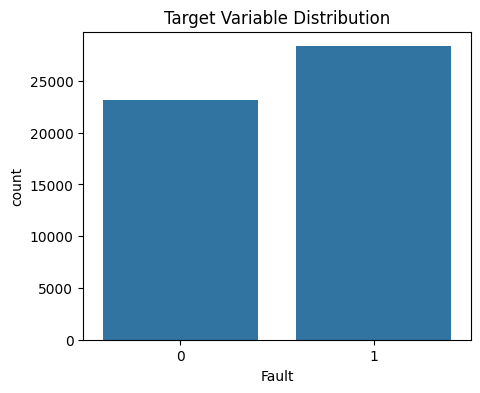

In [15]:
plt.figure(figsize=(5,4))

sns.countplot(data=train, x="Fault")

plt.title("Target Variable Distribution")
plt.show()

In [16]:
train.dtypes.value_counts()

str        37
int64       3
float64     2
Name: count, dtype: int64

In [17]:
num_cols = train.select_dtypes(include=["int64","float64"]).columns.tolist()

cat_cols = train.select_dtypes(include=["object"]).columns.tolist()

date_cols = train.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print(f"Numerical Columns   : {len(num_cols)}")
print(f"Categorical Columns : {len(cat_cols)}")
print(f"Date Columns        : {len(date_cols)}")

Numerical Columns   : 5
Categorical Columns : 37
Date Columns        : 0


In [18]:
unique = pd.DataFrame({
    "Unique Values": train.nunique()
})

unique.sort_values("Unique Values")

,Unique Values
Parked Vehicle,2
Fault,2
Driverless Vehicle,2
ACRS Report Type,3
Vehicle Going Dir,5
Vehicle Continuing Dir,5
Injury Severity,5
Vehicle Damage Extent,7
Equipment Problems,8
Light,8


In [19]:
high_cardinality = unique[unique["Unique Values"] > 100]

high_cardinality.sort_values(
    by="Unique Values",
    ascending=False
)

,Unique Values
Person ID,49209
Vehicle ID,49160
Crash Date/Time,39573
Location,38953
Longitude,37669
Latitude,37080
Cross-Street Name,4525
Off-Road Description,4017
Report Number,3256
Vehicle Model,3128


In [20]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Speed Limit,51490.0,32.895319,11.696668,0.00000,25.000000,35.000000,40.000000,70.000000
Vehicle Year,51490.0,1974.545465,483.279428,0.00000,2005.000000,2010.000000,2014.000000,9999.000000
Latitude,51490.0,39.082783,0.072062,38.00812,39.023974,39.074522,39.139685,39.989747
Longitude,51490.0,-77.112688,0.098300,-79.48600,-77.188926,-77.105670,-77.040114,-75.975952
Fault,51490.0,0.550204,0.497478,0.00000,0.000000,1.000000,1.000000,1.000000


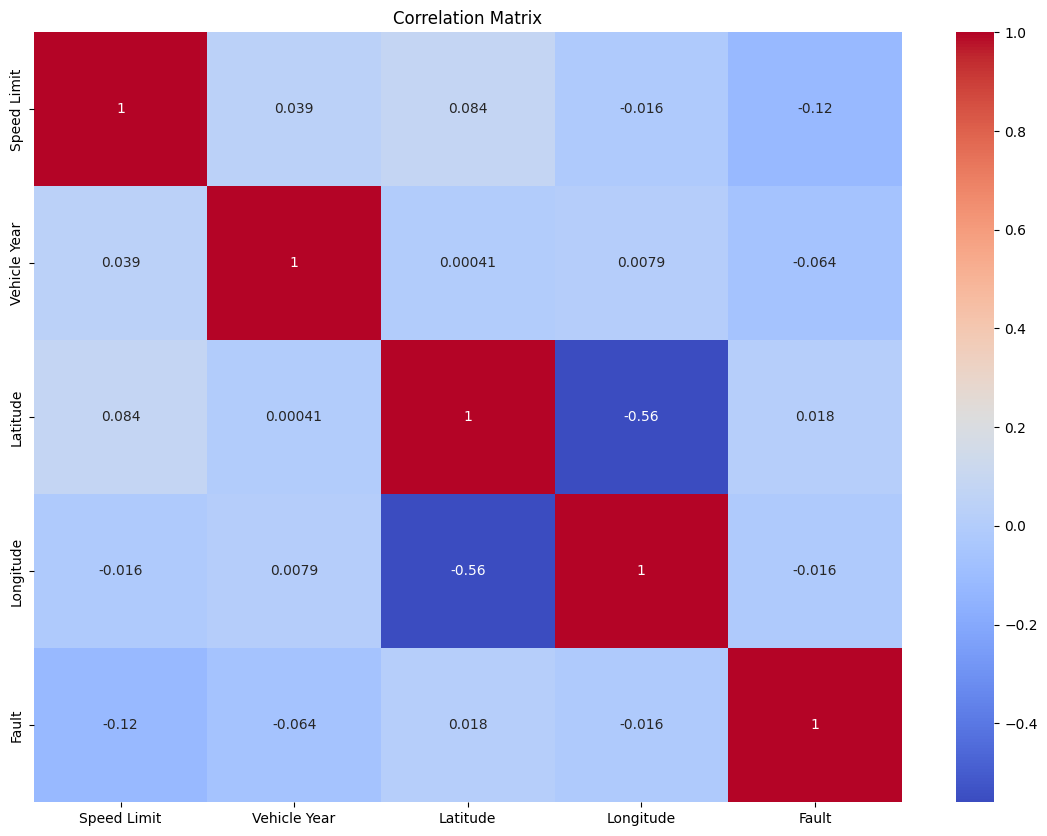

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    train[num_cols].corr(),
    annot = True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

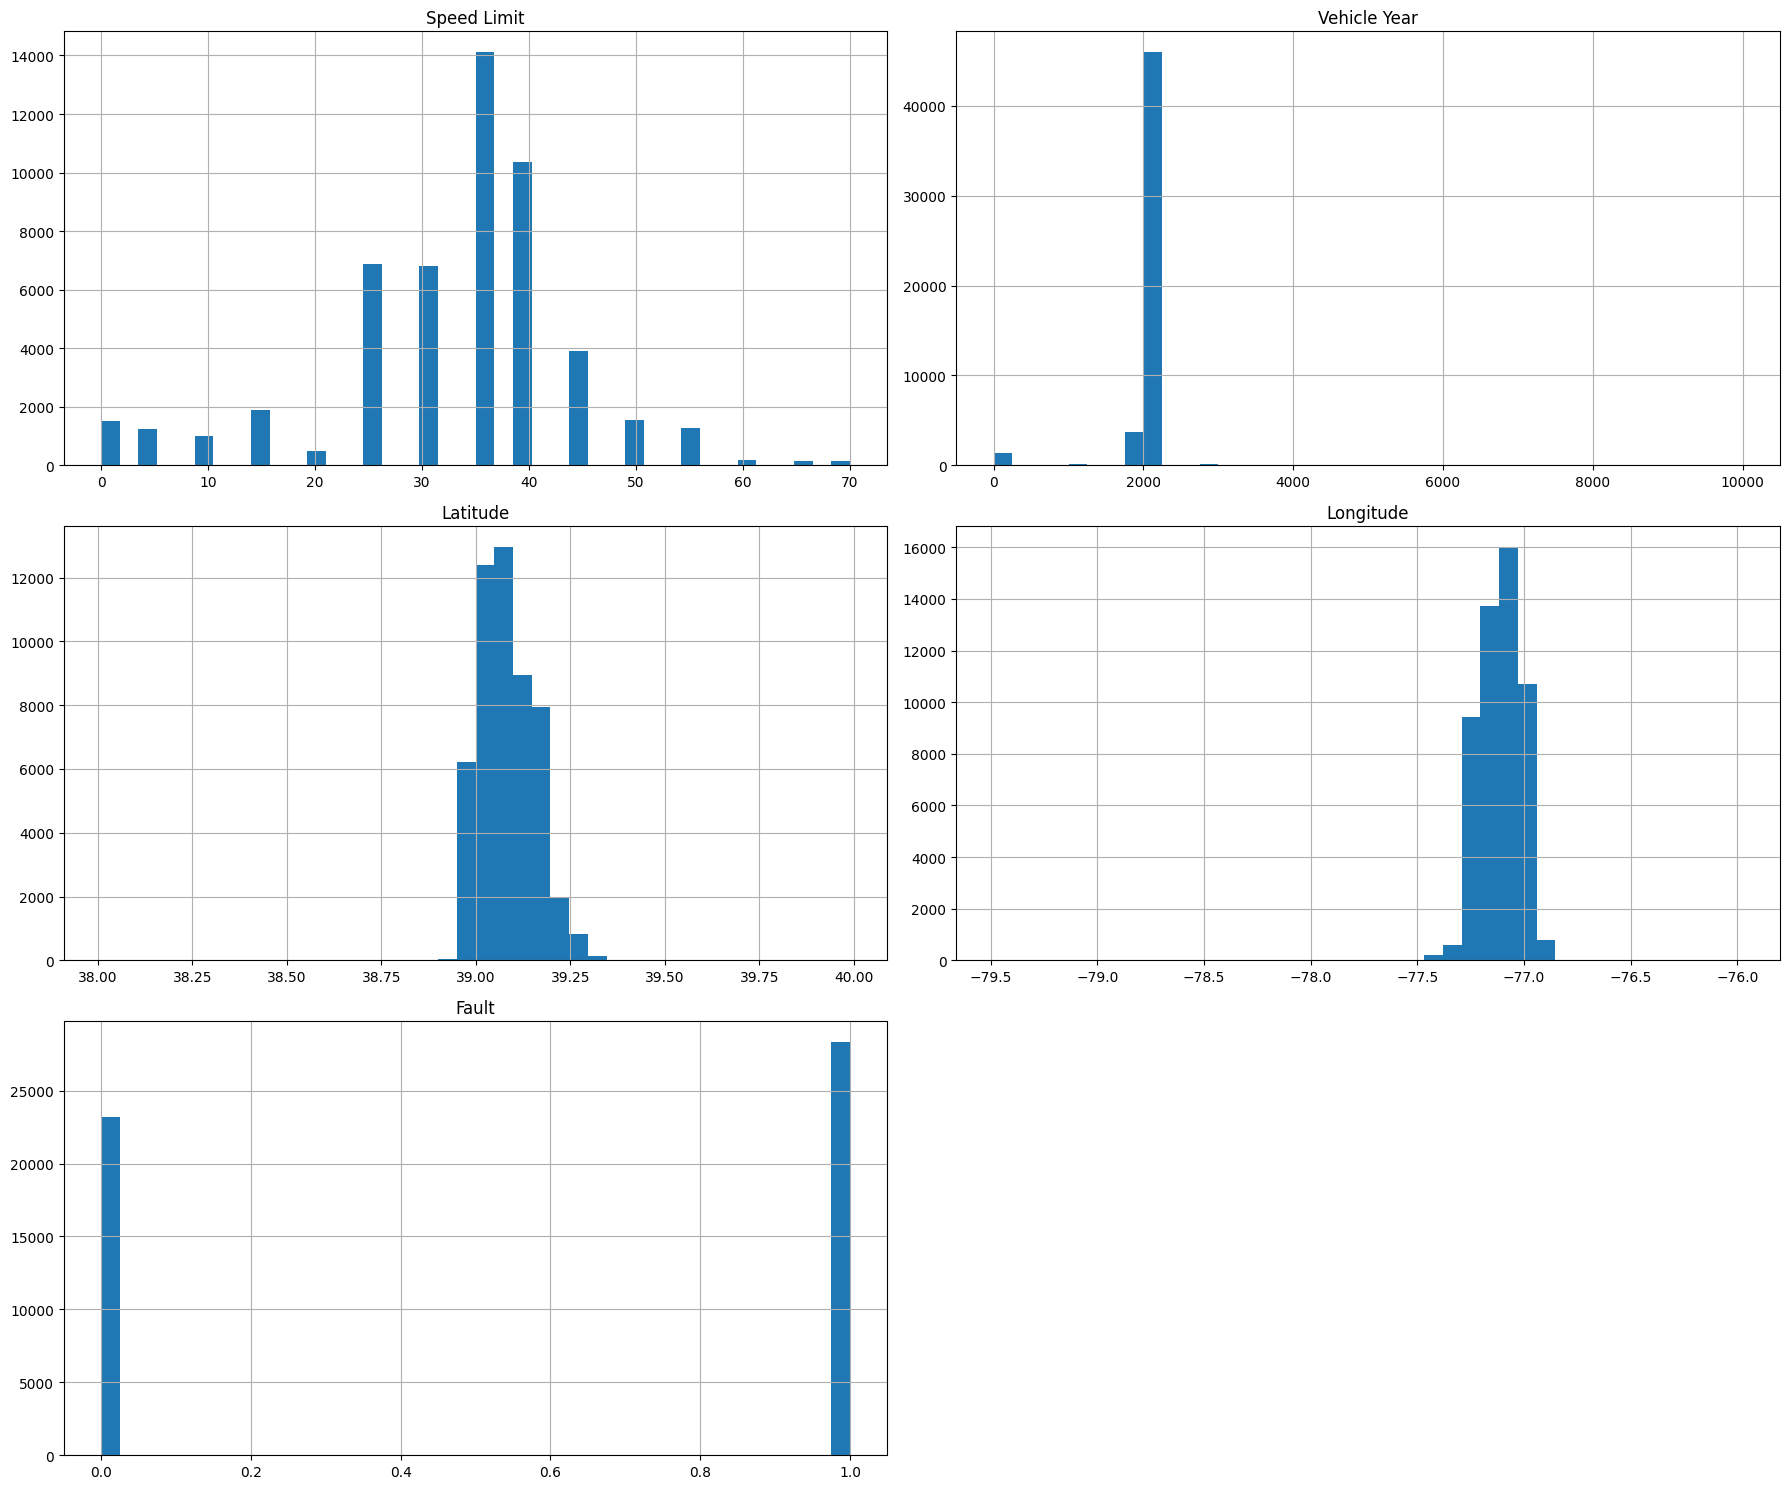

In [22]:
train[num_cols].hist(
    figsize=(18,15),
    bins=40
)

plt.tight_layout()
plt.show()

# EDA

In [23]:
# ============================================
# Column Summary
# ============================================

column_summary = pd.DataFrame({
    "Data Type": train.dtypes,
    "Missing Values": train.isnull().sum(),
    "Missing %": round(train.isnull().mean() * 100, 2),
    "Unique Values": train.nunique()
})

column_summary.sort_values(
    by=["Missing %", "Unique Values"],
    ascending=False
)

,Data Type,Missing Values,Missing %,Unique Values
Non-Motorist Substance Abuse,str,48106,93.43,9
Related Non-Motorist,str,47842,92.92,11
Off-Road Description,str,44540,86.50,4017
Municipality,str,43923,85.30,20
Circumstance,str,39738,77.18,139
Equipment Problems,str,10666,20.71,8
Driver Substance Abuse,str,9095,17.66,11
Traffic Control,str,7774,15.10,11
Local Case Number,str,6453,12.53,1429
Surface Condition,str,5879,11.42,11


In [24]:
# ============================================
# Potential ID Columns
# ============================================

id_columns = [
    col for col in train.columns
    if "ID" in col.upper()
    or "NUMBER" in col.upper()
]

id_columns

['Report Number', 'Local Case Number', 'Person ID', 'Vehicle ID']

In [25]:
# ============================================
# Unique Percentage
# ============================================

unique_percent = (
    train.nunique() / len(train) * 100
).sort_values(ascending=False)

unique_percent.to_frame(
    name="Unique %"
)

,Unique %
Person ID,95.570014
Vehicle ID,95.474849
Crash Date/Time,76.855700
Location,75.651583
Longitude,73.157895
Latitude,72.013983
Cross-Street Name,8.788114
Off-Road Description,7.801515
Report Number,6.323558
Vehicle Model,6.074966


In [26]:
# ============================================
# Columns Having >40% Missing Values
# ============================================

high_missing = column_summary[
    column_summary["Missing %"] > 40
]

high_missing

,Data Type,Missing Values,Missing %,Unique Values
Off-Road Description,str,44540,86.50,4017
Municipality,str,43923,85.30,20
Related Non-Motorist,str,47842,92.92,11
Non-Motorist Substance Abuse,str,48106,93.43,9
Circumstance,str,39738,77.18,139


In [27]:
# ============================================
# Categorical Columns
# ============================================

cat_cols = train.select_dtypes(
    include="object"
).columns

cat_cols

Index(['Report Number', 'Local Case Number', 'Agency Name', 'ACRS Report Type',
       'Crash Date/Time', 'Route Type', 'Road Name', 'Cross-Street Type',
       'Cross-Street Name', 'Off-Road Description', 'Municipality',
       'Related Non-Motorist', 'Collision Type', 'Weather',
       'Surface Condition', 'Light', 'Traffic Control',
       'Driver Substance Abuse', 'Non-Motorist Substance Abuse', 'Person ID',
       'Injury Severity', 'Circumstance', 'Drivers License State',
       'Vehicle ID', 'Vehicle Damage Extent', 'Vehicle First Impact Location',
       'Vehicle Second Impact Location', 'Vehicle Body Type',
       'Vehicle Movement', 'Vehicle Continuing Dir', 'Vehicle Going Dir',
       'Driverless Vehicle', 'Parked Vehicle', 'Vehicle Make', 'Vehicle Model',
       'Equipment Problems', 'Location'],
      dtype='str')

In [28]:
# ============================================
# Cardinality
# ============================================

cardinality = train[cat_cols].nunique()

cardinality.sort_values(
    ascending=False
)

Person ID                         49209
Vehicle ID                        49160
Crash Date/Time                   39573
Location                          38953
Cross-Street Name                  4525
Off-Road Description               4017
Report Number                      3256
Vehicle Model                      3128
Road Name                          2226
Local Case Number                  1429
Vehicle Make                        886
Circumstance                        139
Drivers License State                65
Vehicle Body Type                    30
Vehicle Movement                     22
Municipality                         20
Collision Type                       18
Vehicle First Impact Location        16
Vehicle Second Impact Location       16
Weather                              12
Related Non-Motorist                 11
Traffic Control                      11
Driver Substance Abuse               11
Surface Condition                    11
Agency Name                          10


In [29]:
# Make a copy of the dataset

train_df = train.copy()
test_df = test.copy()

In [30]:
# ============================================
# Drop Unnecessary Columns
# ============================================

drop_columns = [
    "Report Number",             # Unique Report ID
    "Person ID",                 # Unique Person ID
    "Vehicle ID",                # Unique Vehicle ID
    "Off-Road Description",      # Too many missing values
    "Municipality",              # High missing values
    "Related Non-Motorist",      # High missing values
    "Non-Motorist Substance Abuse", # High missing values
    "Circumstance"               # High missing values
]

# Drop only if column exists
train_df.drop(columns=[col for col in drop_columns if col in train_df.columns],
              inplace=True)

test_df.drop(columns=[col for col in drop_columns if col in test_df.columns],
             inplace=True)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (51490, 34)
Test Shape  : (77235, 34)


In [31]:
# Convert to datetime

train_df["Crash Date/Time"] = pd.to_datetime(
    train_df["Crash Date/Time"],
    errors="coerce"
)

test_df["Crash Date/Time"] = pd.to_datetime(
    test_df["Crash Date/Time"],
    errors="coerce"
)

# FEATURE ENGINEERING

In [32]:
# ============================================
# Feature Engineering
# ============================================

def feature_engineering(df):

    df = df.copy()

    # -------------------------------
    # Date Features
    # -------------------------------
    if "Crash Date/Time" in df.columns:

        df["Crash Year"] = df["Crash Date/Time"].dt.year
        df["Crash Month"] = df["Crash Date/Time"].dt.month
        df["Crash Day"] = df["Crash Date/Time"].dt.day
        df["Crash Hour"] = df["Crash Date/Time"].dt.hour
        df["Crash DayOfWeek"] = df["Crash Date/Time"].dt.dayofweek

        # Weekend
        df["Is Weekend"] = (df["Crash DayOfWeek"] >= 5).astype(int)

        # Rush Hour
        df["Rush Hour"] = (
            df["Crash Hour"].between(7, 9) |
            df["Crash Hour"].between(16, 19)
        ).astype(int)

        # Night Driving
        df["Night"] = (
            (df["Crash Hour"] >= 20) |
            (df["Crash Hour"] <= 5)
        ).astype(int)

        # Drop Original Date Column
        df.drop(columns=["Crash Date/Time"], inplace=True)

    # -------------------------------
    # Location Features
    # -------------------------------
    if "Location" in df.columns:

        location_split = (
            df["Location"]
            .astype(str)
            .str.replace(",", " ", regex=False)
            .str.split(expand=True, n=1)
        )

        if location_split.shape[1] == 2:

            df["Location_X"] = pd.to_numeric(
                location_split[0],
                errors="coerce"
            )

            df["Location_Y"] = pd.to_numeric(
                location_split[1],
                errors="coerce"
            )

        df.drop(columns=["Location"], inplace=True)

    return df

In [33]:
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

In [34]:
print(train_df.shape)
train_df.head()

(51490, 42)


,Local Case Number,Agency Name,ACRS Report Type,Route Type,Road Name,Cross-Street Type,Cross-Street Name,Collision Type,Weather,Surface Condition,...,Crash Year,Crash Month,Crash Day,Crash Hour,Crash DayOfWeek,Is Weekend,Rush Hour,Night,Location_X,Location_Y
0,10196,Montgomery County Police,Injury Crash,Maryland (State),OLD HUNDRED RD,County,THURSTON RD,SINGLE VEHICLE,CLEAR,WET,...,2017,6,5,16,0,0,1,0,3.6383,7.4233
1,20080,Montgomery County Police,Injury Crash,County,JANET RD,County,FLACK ST,STRAIGHT MOVEMENT ANGLE,CLEAR,DRY,...,2020,2,22,10,5,1,0,0,3.0862,7.3240
2,10103,Montgomery County Police,Property Damage Crash,Maryland (State),COLESVILLE RD,Maryland (State),STRUC #15082,SAME DIRECTION RIGHT TURN,CLEAR,DRY,...,2017,6,11,8,6,1,1,0,3.9583,7.3783
3,10208,Montgomery County Police,Injury Crash,County,PARKLAND DR,County,FRANKFORT DR,OTHER,CLOUDY,DRY,...,2019,5,10,7,4,0,1,0,3.8400,-70633.0000
4,1091,Montgomery County Police,Injury Crash,Maryland (State),OLD GEORGETOWN RD,County,MCKINLEY ST,SAME DIR REAR END,CLEAR,DRY,...,2016,8,2,17,1,0,1,0,3.9917,7.0183


In [35]:
# ============================================
# Features & Target
# ============================================

X = train_df.drop("Fault", axis=1)
y = train_df["Fault"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (51490, 41)
Target Shape  : (51490,)


In [36]:
# ============================================
# Numerical & Categorical Columns
# ============================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features :", len(numerical_features))
print("Categorical Features :", len(categorical_features))

Numerical Features : 9
Categorical Features : 27


In [37]:
# ============================================
# Numerical Pipeline
# ============================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)


# ============================================
# Categorical Pipeline
# ============================================

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [38]:
# ============================================
# Column Transformer
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [39]:
# ============================================
# Train Test Split
# ============================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(41192, 41)
(10298, 41)


In [40]:
# ============================================
# Model Evaluation Function
# ============================================

def evaluate_model(model, model_name):

    # Create Pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train Model
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_valid)

    # Accuracy
    accuracy = accuracy_score(y_valid, y_pred)

    print("=" * 60)
    print(f"Model : {model_name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}\n")

    print("Classification Report\n")
    print(classification_report(y_valid, y_pred))

    return pipeline, accuracy

In [41]:
logistic_pipeline, logistic_acc = evaluate_model(
    LogisticRegression(max_iter=1000),
    "Logistic Regression"
)

Model : Logistic Regression
Accuracy : 0.8223

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      4632
           1       0.83      0.86      0.84      5666

    accuracy                           0.82     10298
   macro avg       0.82      0.82      0.82     10298
weighted avg       0.82      0.82      0.82     10298



In [42]:
rf_pipeline, rf_acc = evaluate_model(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest"
)

Model : Random Forest
Accuracy : 0.8357

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.76      0.81      4632
           1       0.82      0.90      0.86      5666

    accuracy                           0.84     10298
   macro avg       0.84      0.83      0.83     10298
weighted avg       0.84      0.84      0.83     10298



In [43]:
et_pipeline, et_acc = evaluate_model(
    ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees"
)

Model : Extra Trees
Accuracy : 0.8446

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      4632
           1       0.84      0.89      0.86      5666

    accuracy                           0.84     10298
   macro avg       0.85      0.84      0.84     10298
weighted avg       0.85      0.84      0.84     10298



In [44]:
xgb_pipeline, xgb_acc = evaluate_model(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    "XGBoost"
)

Model : XGBoost
Accuracy : 0.8497

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      4632
           1       0.86      0.87      0.86      5666

    accuracy                           0.85     10298
   macro avg       0.85      0.85      0.85     10298
weighted avg       0.85      0.85      0.85     10298



In [45]:
cat_pipeline, cat_acc = evaluate_model(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    "CatBoost"
)

Model : CatBoost
Accuracy : 0.8537

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      4632
           1       0.86      0.88      0.87      5666

    accuracy                           0.85     10298
   macro avg       0.85      0.85      0.85     10298
weighted avg       0.85      0.85      0.85     10298



In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "CatBoost"
    ],
    "Accuracy": [
        logistic_acc,
        rf_acc,
        et_acc,
        xgb_acc,
        cat_acc
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy
0,CatBoost,0.853661
1,XGBoost,0.849680
2,Extra Trees,0.844630
3,Random Forest,0.835696
4,Logistic Regression,0.822296


In [47]:
from scipy.stats import randint, uniform

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

param_dist = {

    "model__n_estimators": randint(200, 600),

    "model__max_depth": randint(4, 10),

    "model__learning_rate": uniform(0.01, 0.25),

    "model__subsample": uniform(0.7, 0.3),

    "model__colsample_bytree": uniform(0.6, 0.4),

    "model__min_child_weight": randint(1, 8),

    "model__gamma": uniform(0, 0.5)

}

xgb_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=param_dist,

    n_iter=20,

    scoring="accuracy",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': <scipy.stats....0024171058E10>, 'model__gamma': <scipy.stats....002417254DBA0>, 'model__learning_rate': <scipy.stats....0024171831D30>, 'model__max_depth': <scipy.stats....002417105B110>, ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [48]:
print(xgb_search.best_params_)
print(xgb_search.best_score_)

{'model__colsample_bytree': np.float64(0.6161734358153725), 'model__gamma': np.float64(0.3553314448428937), 'model__learning_rate': np.float64(0.03772270520295783), 'model__max_depth': 7, 'model__min_child_weight': 5, 'model__n_estimators': 378, 'model__subsample': np.float64(0.7094287557060203)}
0.8540978147944271


In [49]:
best_xgb = xgb_search.best_estimator_

pred = best_xgb.predict(X_valid)

print("Validation Accuracy :", accuracy_score(y_valid, pred))

Validation Accuracy : 0.8525927364536803


### CatBoost tuning is skipped due to longer training time; XGBoost is used for faster hyperparameter optimization.

In [50]:
# ============================================
# Train Final Model on Complete Dataset
# ============================================

X = train_df.drop(columns="Fault")
y = train_df["Fault"]

best_xgb.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
# ============================================
# Predict Test Dataset
# ============================================

test_predictions = best_xgb.predict(test_df)

In [52]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "Fault": test_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,Id,Fault
0,0,1
1,1,0
2,2,0
3,3,1
4,4,1


In [53]:
submission.info()
submission.head()

<class 'pandas.DataFrame'>
RangeIndex: 77235 entries, 0 to 77234
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Id      77235 non-null  int64
 1   Fault   77235 non-null  int64
dtypes: int64(2)
memory usage: 1.2 MB


,Id,Fault
0,0,1
1,1,0
2,2,0
3,3,1
4,4,1


In [54]:
# ============================================
# Save Final Model
# ============================================

joblib.dump(best_xgb, "best_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [55]:
print("=" * 50)
print("Driver Fault Classification Project Completed")
print("=" * 50)
print("Best Model : Tuned XGBoost")
print("Validation Accuracy :", round(accuracy_score(y_valid, pred), 4))
print("Model Saved : best_model.pkl")
print("Submission Saved : submission.csv")

Driver Fault Classification Project Completed
Best Model : Tuned XGBoost
Validation Accuracy : 0.8526
Model Saved : best_model.pkl
Submission Saved : submission.csv
